# F-NORM Visual Ground-Truth Check

Visual inspection of the normalized 128×128 eye patch produced by `compose_warp` + `normalize_eye`.
The eye should be visible and approximately centred (brow at top, iris centred).

**How the warp is positioned (verified empirically):** the composed homography `H_crop`
maps the face crop into EVE's *own* normalized-patch frame, whose principal point — where
the eye centre lands, by the Zhang construction — sits at **~(63, 61)**. EVE's native eye
patch is ~128 px, so `normalize_eye` warps **directly to 128×128** and the eye is centred with
no intermediate canvas or center-crop.

> Earlier the code warped to a 256×256 canvas and center-cropped `[64:192]`, assuming the eye
> sat at (128, 128). It actually sits at ~(63, 61), so that crop landed on the cheek. Fixed:
> warp straight to the output size.

Note on patch naming: `get_warp_matrix(exp_key, 'left')` centres the eye that appears on the
**image-right** side; EVE's patch labels (`left`/`right`) and `get_eye_coords_in_crop`'s labels
use opposite left/right conventions. This does not affect correctness — each patch's `W`,
`g_tobii`, and `o` come from the same HDF group, so image and label stay in the same frame.

In [1]:
import sys
sys.path.insert(0, '../src')

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import cv2

from evedataset import EveBundle
from eye_norm import compose_warp, normalize_eye

BUNDLE_DIR   = Path('../..') / 'eve_shared' / 'EveDataset' / 'bundle'
CROPS_ROOT   = Path('../..') / 'eve_shared' / 'EveDataset' / 'eve_out'

bundle = EveBundle.load(BUNDLE_DIR)
print(bundle)

EveBundle(..\..\eve_shared\EveDataset\bundle, 3096 samples, 29844 webgazer runs)


In [2]:
# Pick first exp_key with both gaze-norm and face-crop coverage
exp_key = next(
    ek for ek in bundle.samples_df['exp_key']
    if bundle.has_gaze_norm(ek) and bundle.has_face_crops(ek)
)
print(f'exp_key: {exp_key}')

# Find first valid left-eye frame
warp_data   = bundle.get_warp_matrix(exp_key, 'left')
frame_val   = bundle.get_frame_validity(exp_key)
combined    = warp_data['validity'] & frame_val
t           = int(np.argmax(combined))
print(f'Using frame {t} (validity={combined[t]})')

exp_key: train13_step027
Using frame 15 (validity=True)


In [3]:
# Fetch data for frame t
W_t        = warp_data['W'][t]                         # (3,3) float32
x0, y0     = bundle.get_crop_origin(exp_key)[t]        # int32 crop origin
face_crop  = bundle.get_face_crop(exp_key, t, CROPS_ROOT)  # (512,512,3) uint8

# Compose and warp
H_crop     = compose_warp(W_t, int(x0), int(y0))       # (3,3) float64

# Wider 256 canvas for CONTEXT ONLY — lets us see where the eye lands (~(63,61))
# and where the 128×128 production window sits. Not used downstream.
context_256 = cv2.warpPerspective(
    face_crop, H_crop, (256, 256),
    flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT, borderValue=(0, 0, 0),
)

# Production patch: warp directly to 128×128 (eye lands centred by construction).
patch_128  = normalize_eye(face_crop, H_crop)          # (128,128,3) uint8

# Where does the eye centre actually land? (eye-corner midpoint through H_crop)
def _warp_pts(H, pts):
    pts = np.asarray(pts, float)
    hom = np.hstack([pts, np.ones((len(pts), 1))])
    out = (H @ hom.T).T
    return out[:, :2] / out[:, 2:3]

# left_W centres the image-right eye; use that eye's corners as the probe.
eye_center_out = _warp_pts(H_crop, bundle.get_eye_coords_in_crop(exp_key, t)['right']).mean(0)

print(f'patch_128 shape: {patch_128.shape}, dtype: {patch_128.dtype}')
print(f'patch_128 mean: {patch_128.mean():.1f}  (> 5.0 required)')
print(f'eye centre lands at output px: ({eye_center_out[0]:.1f}, {eye_center_out[1]:.1f})  '
      f'— should be near (64, 64)')

patch_128 shape: (128, 128, 3), dtype: uint8
patch_128 mean: 125.6  (> 5.0 required)
eye centre lands at output px: (60.5, 62.8)  — should be near (64, 64)


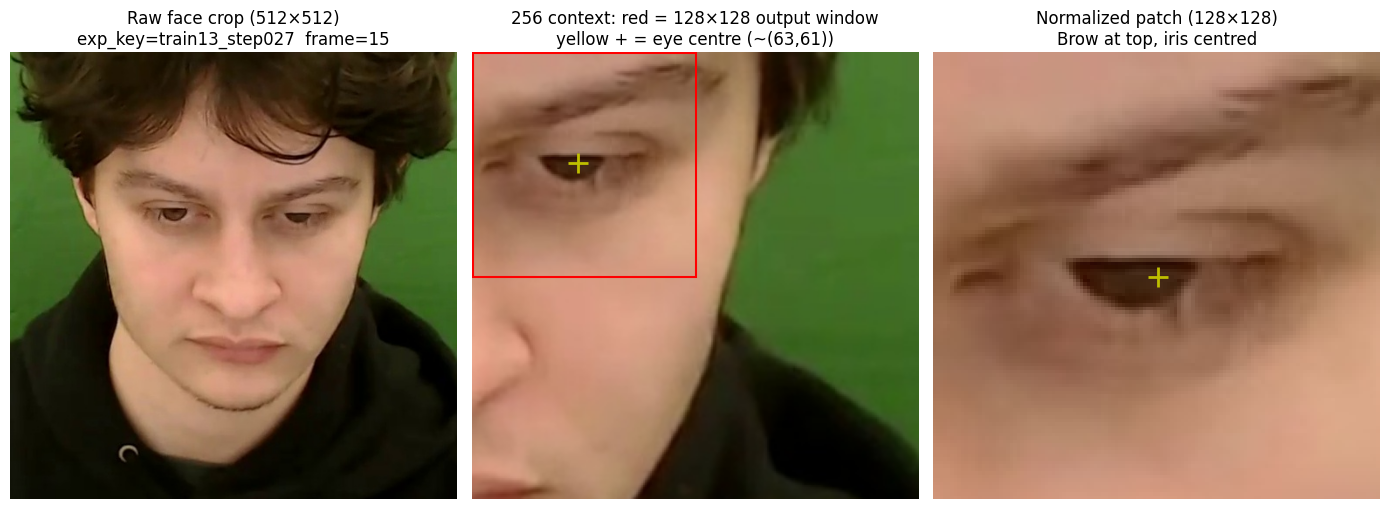

Saved to notebooks/inspect_eye_norm_output.png


In [4]:
# Side-by-side: raw face crop | 256 context (with 128 window) | 128 patch
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

axes[0].imshow(face_crop)
axes[0].set_title(f'Raw face crop (512×512)\nexp_key={exp_key}  frame={t}')
axes[0].axis('off')

axes[1].imshow(context_256)
axes[1].add_patch(mpatches.Rectangle((0, 0), 128, 128, fill=False, ec='r', lw=1.5))
axes[1].plot(*eye_center_out, 'y+', ms=14, mew=2)
axes[1].set_title('256 context: red = 128×128 output window\nyellow + = eye centre (~(63,61))')
axes[1].axis('off')

axes[2].imshow(patch_128)
axes[2].plot(64, 64, 'y+', ms=14, mew=2)
axes[2].set_title('Normalized patch (128×128)\nBrow at top, iris centred')
axes[2].axis('off')

plt.tight_layout()
plt.savefig('../notebooks/inspect_eye_norm_output.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved to notebooks/inspect_eye_norm_output.png')

In [5]:
# DV4 sanity check: 10-experiment spot check (non-trivial patches)
gaze_norm_keys = [
    ek for ek in bundle.samples_df['exp_key']
    if bundle.has_gaze_norm(ek) and bundle.has_face_crops(ek)
][:10]

print('DV4 — normalized patch sanity check (10 experiments):')
all_ok = True
for ek in gaze_norm_keys:
    try:
        wd    = bundle.get_warp_matrix(ek, 'left')
        fv    = bundle.get_frame_validity(ek)
        valid = wd['validity'] & fv
        if not valid.any():
            print(f'  SKIP {ek}: no valid frame')
            continue
        t_i       = int(np.argmax(valid))
        W_i       = wd['W'][t_i]
        xi, yi    = bundle.get_crop_origin(ek)[t_i]
        crop_i    = bundle.get_face_crop(ek, t_i, CROPS_ROOT)
        patch_i   = normalize_eye(crop_i, compose_warp(W_i, int(xi), int(yi)))
        m         = patch_i.mean()
        pct_diff  = (np.abs(patch_i.astype(float) - m) > 10).mean()
        ok = (m > 10) and (m < 245) and (pct_diff > 0.30)
        status = 'OK' if ok else 'FAIL'
        if not ok:
            all_ok = False
        print(f'  {status}  {ek}  mean={m:.1f}  pct_diff>{"0.30"}: {pct_diff:.2f}')
    except Exception as e:
        print(f'  ERROR {ek}: {e}')
        all_ok = False

print()
print('DV4:', 'ALL PASS' if all_ok else 'SOME FAILED — check above')

DV4 — normalized patch sanity check (10 experiments):
  OK  train13_step027  mean=125.6  pct_diff>0.30: 0.79
  OK  train13_step021  mean=127.4  pct_diff>0.30: 0.81
  OK  train13_step062  mean=110.5  pct_diff>0.30: 0.80
  OK  train13_step022  mean=127.3  pct_diff>0.30: 0.80
  OK  train13_step047  mean=116.6  pct_diff>0.30: 0.83
  OK  train13_step058  mean=111.2  pct_diff>0.30: 0.82
  OK  train13_step015  mean=132.5  pct_diff>0.30: 0.81
  OK  train13_step059  mean=110.8  pct_diff>0.30: 0.81
  OK  train13_step020  mean=128.0  pct_diff>0.30: 0.81
  OK  train13_step019  mean=129.8  pct_diff>0.30: 0.81

DV4: ALL PASS


In [6]:
# DV5: W validity == gaze-norm validity for 3 experiments
print('DV5 — W validity == gaze-norm validity (3 experiments):')
for ek in gaze_norm_keys[:3]:
    w_val    = bundle.get_warp_matrix(ek, 'left')['validity']
    gn_val   = bundle.get_normalized_gaze(ek, 'left')['validity']
    match    = np.array_equal(w_val, gn_val)
    print(f'  {"OK" if match else "MISMATCH"}  {ek}')

print()
print('Notebook complete.')

DV5 — W validity == gaze-norm validity (3 experiments):
  OK  train13_step027
  OK  train13_step021
  OK  train13_step062

Notebook complete.


---

## Visual Inspection: Left vs Right patch for the same frame

Both eye patches from `exp_key = train13_step027`, frame 15.

`left_W` centres the **image-right** eye; `right_W` centres the **image-left** eye (EVE's patch labels are the opposite of the anatomical convention — see TechStack §Left/Right Flip Convention).

Check:
- Both patches show a centred, frontalized eye
- Iris and brow visible in both
- Landing points both near (60–66, 60–62)

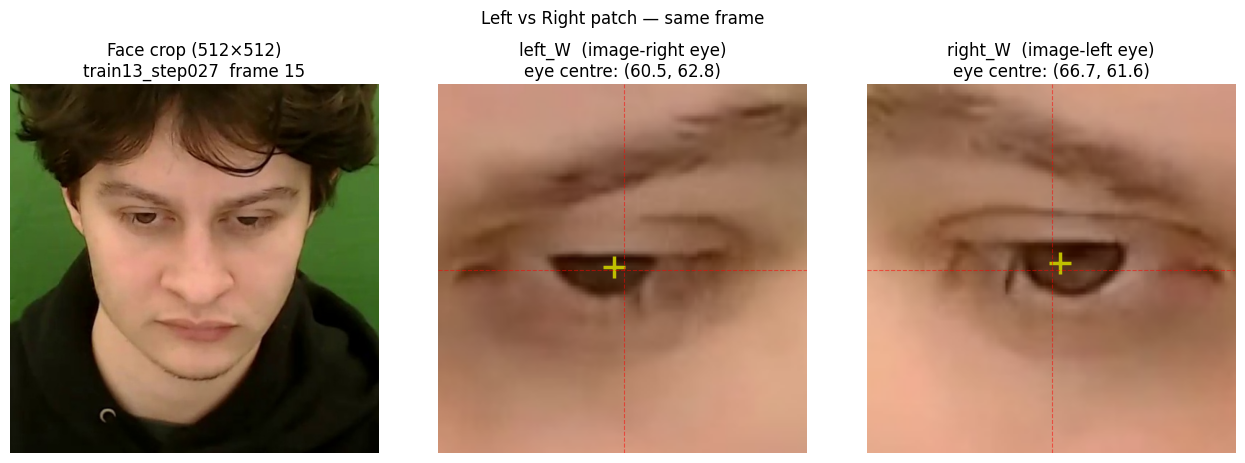

left   eye centre = (60.5, 62.8)  in DV7 band: True
right  eye centre = (66.7, 61.6)  in DV7 band: True


In [7]:
def get_patch_and_center(bundle, exp_key, t, patch, crops_root):
    """Return (normalized 128×128 patch, eye-centre output px) for one frame."""
    warp       = bundle.get_warp_matrix(exp_key, patch)
    W_t        = warp['W'][t]
    x0, y0     = bundle.get_crop_origin(exp_key)[t]
    crop       = bundle.get_face_crop(exp_key, t, crops_root)
    H          = compose_warp(W_t, int(x0), int(y0))
    img        = normalize_eye(crop, H)
    # left_W probes the image-right eye corners; right_W probes image-left eye corners
    probe_side = 'right' if patch == 'left' else 'left'
    corners    = bundle.get_eye_coords_in_crop(exp_key, t)[probe_side]
    centre     = _warp_pts(H, corners).mean(0)
    return img, centre

exp_key = 'train13_step027'
t       = 15

patches = ['left', 'right']
imgs, centres = [], []
for p in patches:
    img, ctr = get_patch_and_center(bundle, exp_key, t, p, CROPS_ROOT)
    imgs.append(img)
    centres.append(ctr)

face_crop_ref = bundle.get_face_crop(exp_key, t, CROPS_ROOT)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))

axes[0].imshow(face_crop_ref)
axes[0].set_title(f'Face crop (512×512)\n{exp_key}  frame {t}')
axes[0].axis('off')

labels = ['left_W  (image-right eye)', 'right_W  (image-left eye)']
for ax, img, ctr, label in zip(axes[1:], imgs, centres, labels):
    ax.imshow(img)
    ax.plot(ctr[0], ctr[1], 'y+', ms=16, mew=2.5)
    ax.axhline(64, color='r', lw=0.8, ls='--', alpha=0.5)
    ax.axvline(64, color='r', lw=0.8, ls='--', alpha=0.5)
    ax.set_title(f'{label}\neye centre: ({ctr[0]:.1f}, {ctr[1]:.1f})')
    ax.axis('off')

plt.suptitle('Left vs Right patch — same frame', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

for p, ctr in zip(patches, centres):
    in_band = (56 <= ctr[0] <= 70) and (56 <= ctr[1] <= 66)
    print(f'{p:5s}  eye centre = ({ctr[0]:.1f}, {ctr[1]:.1f})  in DV7 band: {in_band}')

---

## Visual Inspection: Multi-frame strip

8 consecutive valid frames from the same exp_key, left patch.

Each title shows the frame index and eye-centre landing point (x, y).
The red crosshair marks (64, 64) — the geometric centre of the 128×128 patch.
Landing points should stay near (60, 62) across frames with only small variation (~1.4 px std).

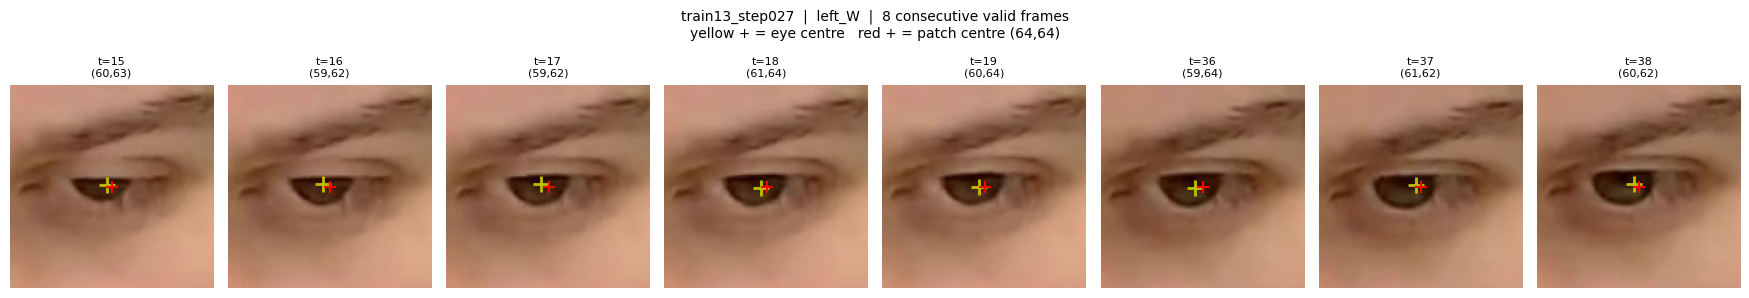

x  range: 59.1–61.0   std=0.69 px
y  range: 61.8–64.2   std=0.97 px


In [8]:
exp_key_strip = 'train13_step027'
patch_strip   = 'left'
N_FRAMES      = 8

wd_strip   = bundle.get_warp_matrix(exp_key_strip, patch_strip)
fv_strip   = bundle.get_frame_validity(exp_key_strip)
valid_idx  = np.where(wd_strip['validity'] & fv_strip)[0][:N_FRAMES]

strip_imgs, strip_ctrs, strip_ts = [], [], []
for t_i in valid_idx:
    img, ctr = get_patch_and_center(bundle, exp_key_strip, int(t_i), patch_strip, CROPS_ROOT)
    strip_imgs.append(img)
    strip_ctrs.append(ctr)
    strip_ts.append(int(t_i))

fig, axes = plt.subplots(1, N_FRAMES, figsize=(2.2 * N_FRAMES, 3.2))
for ax, img, ctr, t_i in zip(axes, strip_imgs, strip_ctrs, strip_ts):
    ax.imshow(img)
    ax.plot(ctr[0], ctr[1], 'y+', ms=12, mew=2)    # eye centre
    ax.plot(64, 64, 'r+', ms=8, mew=1.5)             # patch centre
    ax.set_title(f't={t_i}\n({ctr[0]:.0f},{ctr[1]:.0f})', fontsize=8)
    ax.axis('off')

plt.suptitle(
    f'{exp_key_strip}  |  {patch_strip}_W  |  {N_FRAMES} consecutive valid frames\n'
    f'yellow + = eye centre   red + = patch centre (64,64)',
    fontsize=10,
)
plt.tight_layout()
plt.show()

xs = [c[0] for c in strip_ctrs]
ys = [c[1] for c in strip_ctrs]
print(f'x  range: {min(xs):.1f}–{max(xs):.1f}   std={np.std(xs):.2f} px')
print(f'y  range: {min(ys):.1f}–{max(ys):.1f}   std={np.std(ys):.2f} px')

---

## Visual Inspection: Multi-experiment grid

First valid left-eye patch for each of 12 different experiments sampled evenly across the dataset.
Shows that the warp produces a consistent, centred eye across different subjects and sessions.

Each cell title shows a shortened `exp_key` and the frame index used.
All patches should show a frontalized eye with the iris near the red crosshair (64, 64).

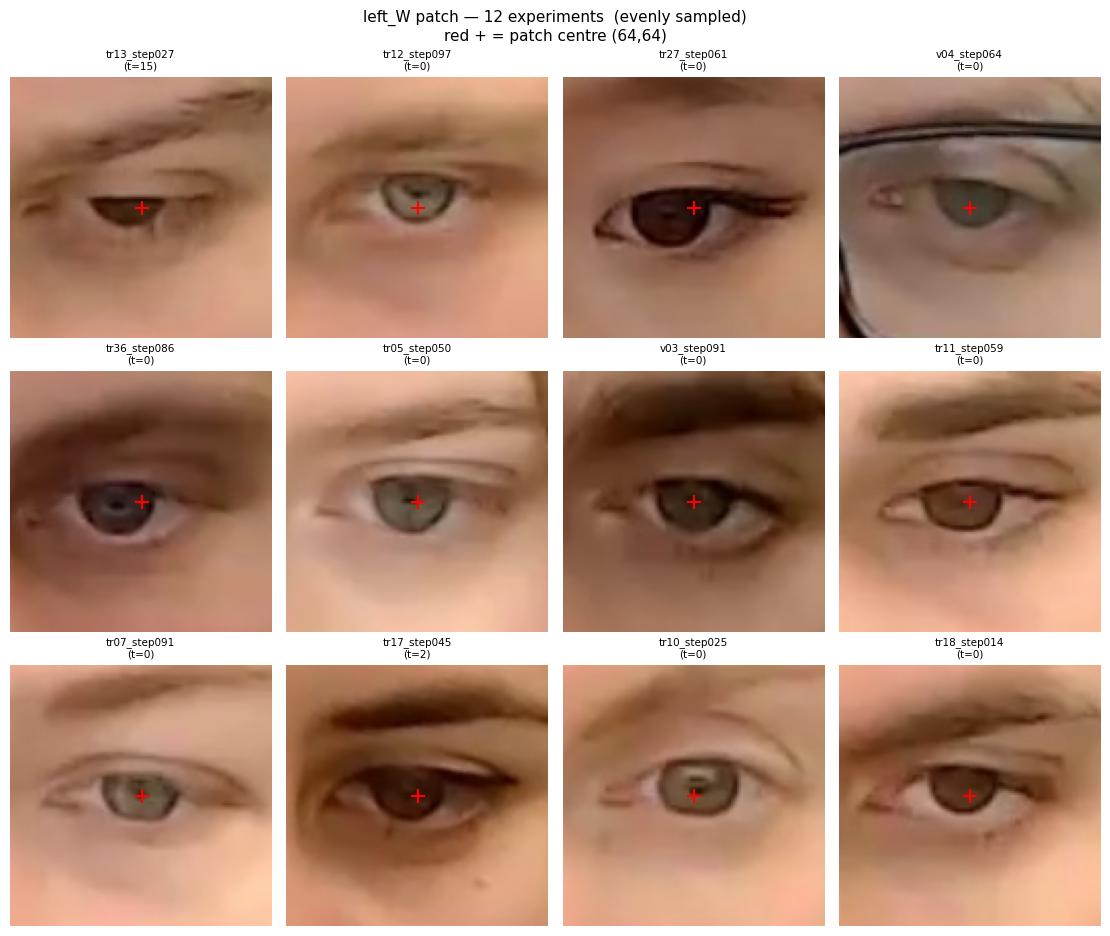

In [9]:
N_EXP  = 12
NCOLS  = 4
NROWS  = N_EXP // NCOLS

all_keys = [
    ek for ek in bundle.samples_df['exp_key']
    if bundle.has_gaze_norm(ek) and bundle.has_face_crops(ek)
]
# Sample evenly to get variety across sessions, not all from the same participant
step        = max(1, len(all_keys) // N_EXP)
sample_keys = all_keys[::step][:N_EXP]

grid_imgs, grid_titles = [], []
for ek in sample_keys:
    wd    = bundle.get_warp_matrix(ek, 'left')
    fv    = bundle.get_frame_validity(ek)
    valid = wd['validity'] & fv
    if not valid.any():
        grid_imgs.append(np.zeros((128, 128, 3), dtype=np.uint8))
        grid_titles.append(f'{ek}\n(no valid frame)')
        continue
    t_i    = int(np.argmax(valid))
    img, _ = get_patch_and_center(bundle, ek, t_i, 'left', CROPS_ROOT)
    grid_imgs.append(img)
    short  = ek.replace('train', 'tr').replace('val', 'v').replace('test', 'te')
    grid_titles.append(f'{short}\n(t={t_i})')

fig, axes = plt.subplots(NROWS, NCOLS, figsize=(NCOLS * 2.8, NROWS * 3.2))
for ax, img, title in zip(axes.flat, grid_imgs, grid_titles):
    ax.imshow(img)
    ax.plot(64, 64, 'r+', ms=10, mew=1.5)
    ax.set_title(title, fontsize=7.5)
    ax.axis('off')

plt.suptitle(
    f'left_W patch — {N_EXP} experiments  (evenly sampled)\nred + = patch centre (64,64)',
    fontsize=11,
)
plt.tight_layout()
plt.show()

---

## DV7 — Eye landing point regression guard (40 experiments)

For each of 40 experiments, the eye-corner midpoint is warped through `compose_warp(W, x0, y0)` and its output pixel position is recorded.

**Expected bands (TechStack §Patch size / intrinsics, empirical across 40 exps):**
- `left_W`: mean ≈ (60, 62) → DV7 band x ∈ [56, 70], y ∈ [56, 66]
- `right_W`: mean ≈ (66, 60) → DV7 band x ∈ [56, 70], y ∈ [56, 66]

The two clusters must be **separated** — if they converge on the same point, the eye-corner pairing convention (`left_W` ↔ `right` corners, `right_W` ↔ `left` corners) is wrong.

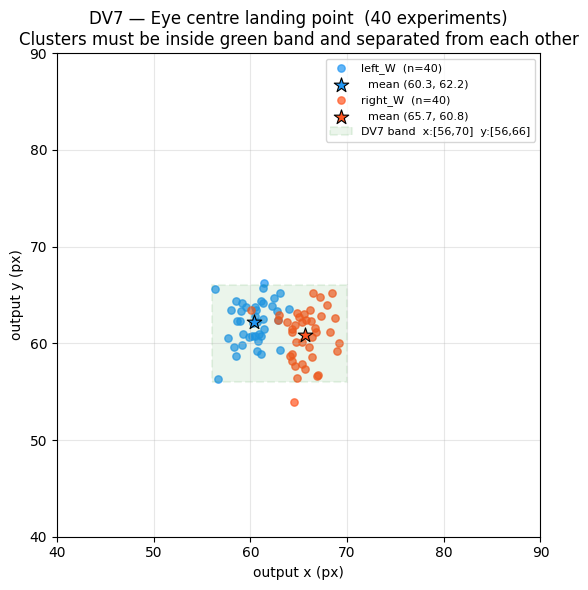

DV7 results:
  left_W  mean=(60.3, 62.2)  std=(1.73, 2.20)  FAIL (1 out-of-band)
  right_W  mean=(65.7, 60.8)  std=(1.81, 2.62)  FAIL (1 out-of-band)

DV7 overall: SOME FAILED — regression detected


In [10]:
N_EXP_DV7 = 40
step40     = max(1, len(all_keys) // N_EXP_DV7)
keys40     = all_keys[::step40][:N_EXP_DV7]

DV7_X = (56, 70)
DV7_Y = (56, 66)

landings = {'left': [], 'right': []}

for ek in keys40:
    fv = bundle.get_frame_validity(ek)
    for patch in ('left', 'right'):
        wd    = bundle.get_warp_matrix(ek, patch)
        valid = wd['validity'] & fv
        if not valid.any():
            continue
        t_i     = int(np.argmax(valid))
        W_t     = wd['W'][t_i]
        x0, y0  = bundle.get_crop_origin(ek)[t_i]
        H       = compose_warp(W_t, int(x0), int(y0))
        probe   = 'right' if patch == 'left' else 'left'
        corners = bundle.get_eye_coords_in_crop(ek, t_i)[probe]
        ctr     = _warp_pts(H, corners).mean(0)
        landings[patch].append(ctr)

fig, ax = plt.subplots(figsize=(6, 6))
colors = {'left': '#2196F3', 'right': '#FF5722'}

for patch, pts in landings.items():
    pts = np.array(pts)
    ax.scatter(pts[:, 0], pts[:, 1], s=28, alpha=0.7,
               color=colors[patch], label=f'{patch}_W  (n={len(pts)})')
    ax.scatter(pts[:, 0].mean(), pts[:, 1].mean(), s=120, marker='*',
               color=colors[patch], edgecolors='k', lw=0.8, zorder=5,
               label=f'  mean ({pts[:,0].mean():.1f}, {pts[:,1].mean():.1f})')

from matplotlib.patches import Rectangle as MplRect
band = MplRect((DV7_X[0], DV7_Y[0]),
               DV7_X[1] - DV7_X[0], DV7_Y[1] - DV7_Y[0],
               fill=True, facecolor='green', alpha=0.08,
               edgecolor='green', lw=1.5, ls='--',
               label='DV7 band  x:[56,70]  y:[56,66]')
ax.add_patch(band)

ax.set_xlim(40, 90)
ax.set_ylim(40, 90)
ax.set_aspect('equal')
ax.set_xlabel('output x (px)')
ax.set_ylabel('output y (px)')
ax.set_title(
    f'DV7 — Eye centre landing point  ({N_EXP_DV7} experiments)\n'
    f'Clusters must be inside green band and separated from each other'
)
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('DV7 results:')
all_pass = True
for patch, pts in landings.items():
    pts  = np.array(pts)
    oob  = int(np.sum(
        (pts[:, 0] < DV7_X[0]) | (pts[:, 0] > DV7_X[1]) |
        (pts[:, 1] < DV7_Y[0]) | (pts[:, 1] > DV7_Y[1])
    ))
    status = 'PASS' if oob == 0 else f'FAIL ({oob} out-of-band)'
    if oob:
        all_pass = False
    print(f'  {patch}_W  mean=({pts[:,0].mean():.1f}, {pts[:,1].mean():.1f})  '
          f'std=({pts[:,0].std():.2f}, {pts[:,1].std():.2f})  {status}')

print()
print('DV7 overall:', 'ALL PASS' if all_pass else 'SOME FAILED — regression detected')